In [1]:
# Imports unificados e setup
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
from bizdays import Calendar
import plotly.express as px
import plotly.graph_objects as go

from analise_liquidez.dados import TITULOS_PUBLICOS_SCHEMA, carregar_dados_resiliente, ajustar_tipos
from analise_liquidez.regras import expandir_dias_uteis, filtrar_periodo_recente, calcular_medias_e_volumes, calcular_liquidez_carteira
from analise_liquidez.graficos import plot_titulo_plotly


In [2]:
# Carregamento resiliente dos dados de títulos públicos (TPF)
url = "https://github.com/PulseDataLabs/PulseFlat/raw/refs/heads/main/data/bacen_negociacao_tpf_extragrupo.csv.gz"
local_path = "../../PulseFlat/data/bacen_negociacao_tpf_extragrupo.csv.gz"
if not os.path.exists(local_path):
    local_path = "../PulseFlat/data/bacen_negociacao_tpf_extragrupo.csv.gz"

df_raw = carregar_dados_resiliente(local_path, url)

# Limpeza de metadados desnecessários
for col in ['arquivo_origem', 'data_captura', 'conjunto', 'registro_hash']:
    if col in df_raw.columns:
        del df_raw[col]

# Ajuste de tipos de dados baseado no schema unificado
df_adjusted = ajustar_tipos(df_raw, TITULOS_PUBLICOS_SCHEMA)

display(df_adjusted.head())


Carregando dados de: https://github.com/PulseDataLabs/PulseFlat/raw/refs/heads/main/data/bacen_negociacao_tpf_extragrupo.csv.gz


,data_mov,sigla,codigo,codigo_isin,emissao,vencimento,num_de_oper,quant_negociada,valor_negociado,pu_min,pu_med,pu_max,pu_lastro,valor_par,taxa_min,taxa_med,taxa_max,num_oper_com_corretagem,quant_neg_com_corretagem
0,2020-01-02,LFT,210100,BRSTNCLF1R25,2014-01-17,2020-03-01,7,534,NaN,NaN,NaN,NaN,10470.804129,10471.890903,NaN,NaN,NaN,7,534
1,2020-01-02,LFT,210100,BRSTNCLF1R33,2014-07-18,2020-09-01,12,4370,NaN,10471.733511,10471.812207,10471.890903,10467.266660,10471.890903,0.0000,0.0012,0.0024,10,4152
2,2020-01-02,LFT,210100,BRSTNCLF1R41,2015-01-09,2021-03-01,15,21759,NaN,10471.105511,10471.353458,10471.890903,10463.743534,10471.890903,0.0000,0.0045,0.0066,12,17071
3,2020-01-02,LFT,210100,BRSTNCLF1R58,2015-05-08,2021-09-01,13,7906,NaN,10470.927489,10470.944114,10471.157870,10459.885246,10471.890903,0.0042,0.0054,0.0056,8,6839
4,2020-01-02,LFT,210100,BRSTNCLF1R66,2016-01-08,2022-03-01,7,10734,NaN,10469.628974,10469.699950,10469.806996,10456.047768,10471.890903,0.0093,0.0097,0.0100,5,10581


In [3]:
# Carrega calendário de negócios ANBIMA e expande o histórico por dia útil
cal = Calendar.load('ANBIMA')
min_date = df_adjusted['data_mov'].min()
max_date = df_adjusted['data_mov'].max()

print(f"Data mínima: {min_date.date()} | Data máxima: {max_date.date()}")

business_days = cal.seq(min_date, max_date)
business_days_ts = pd.to_datetime(business_days)

df_expanded = expandir_dias_uteis(df_adjusted, business_days_ts, TITULOS_PUBLICOS_SCHEMA)

print("DataFrame expandido (primeiras linhas):")
display(df_expanded.head())


Data mínima: 2020-01-02 | Data máxima: 2026-07-31
DataFrame expandido (primeiras linhas):


,data_mov,sigla,codigo,codigo_isin,emissao,vencimento,num_de_oper,quant_negociada,valor_negociado,pu_min,pu_med,pu_max,pu_lastro,valor_par,taxa_min,taxa_med,taxa_max,num_oper_com_corretagem,quant_neg_com_corretagem
0,2020-01-02,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,4,2656,NaN,10462.487144,10463.263008,10463.637353,10434.643618,10471.890903,0.0169,0.0177,0.0193,1,1500
1,2020-01-03,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,13,42715,NaN,10465.416205,10465.416272,10465.427184,10436.463392,10473.680445,0.0170,0.0170,0.0170,7,6874
2,2020-01-06,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,18,8520,NaN,10462.355003,10466.529339,10467.228017,10438.283477,10475.470292,0.0169,0.0184,0.0270,9,6038
3,2020-01-07,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,19,25105,NaN,10467.747092,10468.415665,10468.899591,10440.103870,10477.260445,0.0172,0.0182,0.0196,8,6493
4,2020-01-08,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,8,439,NaN,10470.080836,10470.641868,10470.688621,10441.924572,10479.050904,0.0172,0.0173,0.0185,3,387


In [4]:
# Filtro para os últimos 3 meses usando a data de referência correta do dataset (julho de 2026)
data_referencia = pd.to_datetime('2026-07-31')
print(f"Data de Referência de Análise: {data_referencia.date()}")

df_analise_recent = filtrar_periodo_recente(df_expanded, data_referencia, months_ago=3, schema=TITULOS_PUBLICOS_SCHEMA)
df_analise_recent = ajustar_tipos(df_analise_recent, TITULOS_PUBLICOS_SCHEMA)

display(df_analise_recent.head())


Data de Referência de Análise: 2026-07-31
DataFrame filtrado para o período: 2026-04-30 a 2026-07-31


,data_mov,sigla,codigo,codigo_isin,emissao,vencimento,num_de_oper,quant_negociada,valor_negociado,pu_min,pu_med,pu_max,pu_lastro,valor_par,taxa_min,taxa_med,taxa_max,num_oper_com_corretagem,quant_neg_com_corretagem
1587,2026-04-30,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,18,353129,NaN,15282.175843,15282.191009,15282.206407,15281.68995,15282.236972,0.0756,0.1008,0.126,4,3549
1588,2026-05-04,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,18,353129,NaN,15282.175843,15282.191009,15282.206407,15281.68995,15282.236972,0.0756,0.1008,0.126,4,3549
1589,2026-05-05,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,18,353129,NaN,15282.175843,15282.191009,15282.206407,15281.68995,15282.236972,0.0756,0.1008,0.126,4,3549
1590,2026-05-06,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,18,353129,NaN,15282.175843,15282.191009,15282.206407,15281.68995,15282.236972,0.0756,0.1008,0.126,4,3549
1591,2026-05-07,LFT,210100.0,BRSTNCLF0008,2018-07-06,2024-09-01,18,353129,NaN,15282.175843,15282.191009,15282.206407,15281.68995,15282.236972,0.0756,0.1008,0.126,4,3549


In [5]:
# Identificação dos títulos mais negociados por número de negócios no período recente
top_5_negociados_recentes = df_analise_recent.groupby('codigo_isin')['num_de_oper'].sum().nlargest(5)
top_5_isins = top_5_negociados_recentes.index.tolist()

top_5_info = df_analise_recent[df_analise_recent['codigo_isin'].isin(top_5_isins)][['codigo_isin', 'codigo']].drop_duplicates()
top_5_info = top_5_info.set_index('codigo_isin').loc[top_5_isins].reset_index()
top_5_info = top_5_info.merge(top_5_negociados_recentes.rename('total_negocios'), on='codigo_isin')

print("Top 5 Títulos Públicos Mais Negociados:")
display(top_5_info)


Top 5 Títulos Públicos Mais Negociados:


,codigo_isin,codigo,total_negocios
0,BRSTNCNTB4X0,760199.0,26881
1,BRSTNCNTB3B8,760199.0,24317
2,BRSTNCNTB716,760199.0,17997
3,BRSTNCNTB682,760199.0,14556
4,BRSTNCNTB0O7,760199.0,14392


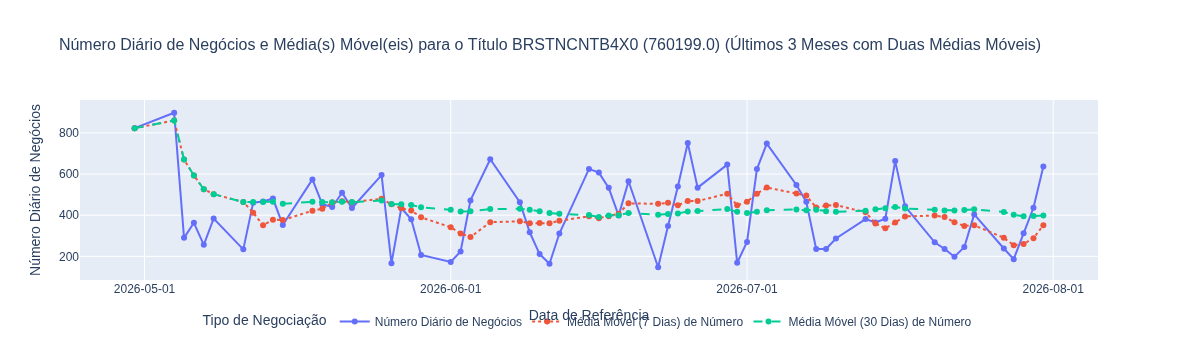

In [6]:
# Gráfico interativo com duas médias móveis (7 e 30 dias) para o título público mais negociado
isin_mais_negociado = top_5_isins[0]
codigo_ativo_mais_negociado = top_5_info[top_5_info['codigo_isin'] == isin_mais_negociado]['codigo'].iloc[0]

fig_plotly = plot_titulo_plotly(
    df_data=df_analise_recent,
    isin_to_plot=isin_mais_negociado,
    codigo_ativo_to_plot=codigo_ativo_mais_negociado,
    schema=TITULOS_PUBLICOS_SCHEMA,
    y_column='num_de_oper',
    title_suffix="(Últimos 3 Meses com Duas Médias Móveis)",
    window_size=7,
    window_size_secondary=30
)
fig_plotly.show()


In [7]:
# Cálculo das médias móveis de quantidade de 21 dias úteis e volumes de liquidez
df_analise = calcular_medias_e_volumes(df_expanded, TITULOS_PUBLICOS_SCHEMA)
display(df_analise.sort_values(by=['data_mov', 'quantidade_media_21_dias'], ascending=[False, False]).head())


,data_mov,sigla,codigo,codigo_isin,emissao,vencimento,num_de_oper,quant_negociada,valor_negociado,pu_min,...,pu_lastro,valor_par,taxa_min,taxa_med,taxa_max,num_oper_com_corretagem,quant_neg_com_corretagem,quantidade_media_21_dias,valor_total_sem_desconto,volume_liquido_1dia_calculado
1651,2026-07-31,LTN,100000.0,BRSTNCLTN7V5,2020-07-03,2022-10-01,20,22517305,NaN,999.487146,...,999.457634,1000.0,13.5917,13.6807,13.8000,5,6340500,22517305,22505850514.498417,22505850514.498417
1651,2026-07-31,LTN,100000.0,BRSTNCLTN8B5,2024-01-05,2026-04-01,50,22213200,NaN,999.451410,...,999.423193,1000.0,14.6010,14.7984,14.8300,4,6230600,22213200,22201038250.7868,22201038250.7868
1651,2026-07-31,LTN,100000.0,BRSTNCLTN7U7,2020-02-06,2026-01-01,23,17333399,NaN,999.443836,...,999.414633,1000.0,14.8920,15.0292,15.0495,1,350000,17333399,17323770903.524464,17323770903.524464
1651,2026-07-31,LTN,100000.0,BRSTNCLTN822,2022-07-08,2024-10-01,30,13738335,NaN,999.595153,...,999.562801,1000.0,10.6320,10.6604,10.7430,2,1500000,13738335,13732813700.54685,13732813700.54685
1651,2026-07-31,LTN,100000.0,BRSTNCLTN848,2023-01-06,2026-07-01,52,9324793,NaN,999.466255,...,999.440373,1000.0,14.1390,14.3019,14.4010,8,484600,9324793,9319847959.699377,9319847959.699377


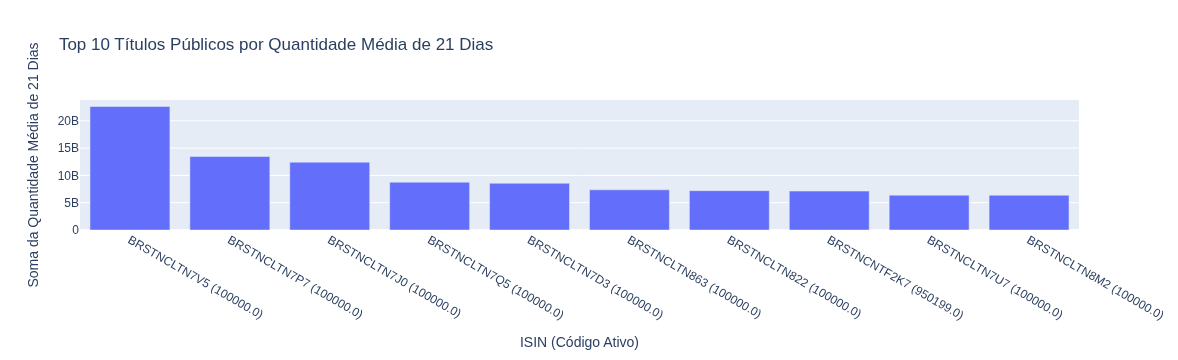

In [8]:
# Gráfico de barras de top 10 ISINs por volume médio diário acumulado
top_10_media_21_dias = df_analise.groupby('codigo_isin')['quantidade_media_21_dias'].sum().nlargest(10).reset_index()
top_10_info_media = pd.merge(
    top_10_media_21_dias,
    df_analise[['codigo_isin', 'codigo']].drop_duplicates(),
    on='codigo_isin',
    how='left'
)
top_10_info_media['isin_codigo'] = top_10_info_media['codigo_isin'] + ' (' + top_10_info_media['codigo'].astype(str) + ')'

fig_bar = px.bar(
    top_10_info_media,
    x='isin_codigo',
    y='quantidade_media_21_dias',
    title='Top 10 Títulos Públicos por Quantidade Média de 21 Dias',
    labels={'isin_codigo': 'ISIN (Código Ativo)', 'quantidade_media_21_dias': 'Soma da Quantidade Média de 21 Dias'}
)
fig_bar.update_layout(xaxis={'categoryorder':'total descending'})
fig_bar.show()


In [9]:
# Análise de Liquidez de Carteira do Fundo
parametros_calculo = {
    "data_referencia": data_referencia,
    "prazo_de_cotizacao": 1,
    "carteira_de_titulos_publicos": [
        ["BRSTNCNTB4U6", "NTB4U6", 4000],
        ["BRSTNCNTB4X0", "NTB4X0", 108353],
        ["BRSTNCNTB633", "NTB633", 27048],
        ["BRSTNCNTB3B8", "NTB3B8", 27048],
        ["BRSTNCNTB682", "NTB682", 27048]
    ]
}

df_analise_liquidez_carteira = calcular_liquidez_carteira(
    parametros=parametros_calculo,
    df_dados_liquidez=df_analise,
    schema=TITULOS_PUBLICOS_SCHEMA
)

print("\n--- Resultado da Análise de Liquidez da Carteira ---")
pd.options.display.float_format = '{:,.2f}'.format
display(df_analise_liquidez_carteira.head())



--- Análise de Liquidez para a Carteira do Fundo na data 2026-07-31 ---
  Ativo: NTB4U6 (ISIN: BRSTNCNTB4U6) - Dados de liquidez encontrados.
  Ativo: NTB4X0 (ISIN: BRSTNCNTB4X0) - Dados de liquidez encontrados.
  Ativo: NTB633 (ISIN: BRSTNCNTB633) - Dados de liquidez encontrados.
  Ativo: NTB3B8 (ISIN: BRSTNCNTB3B8) - Dados de liquidez encontrados.
  Ativo: NTB682 (ISIN: BRSTNCNTB682) - Dados de liquidez encontrados.

--- Resultado da Análise de Liquidez da Carteira ---


,isin,codigo_ativo,quantidade_fundo,data_referencia,pu_med,liquidez_media_21_dias,volume_liquido_1dia_calculado,valor_total_alocado,valor_total_prazo_cotizacao,valor_total_liquido,percentual_liquido_alocado
0,BRSTNCNTB4U6,NTB4U6,4000,2026-07-31,"4,851.86",344945,"1,673,624,255.77","19,407,433.14","1,673,624,255.77","19,407,433.14",100.00
1,BRSTNCNTB4X0,NTB4X0,108353,2026-07-31,"4,661.25",1134906,"5,290,083,327.62","505,060,682.38","5,290,083,327.62","505,060,682.38",100.00
2,BRSTNCNTB633,NTB633,27048,2026-07-31,"4,637.35",206276,"956,573,955.17","125,431,035.79","956,573,955.17","125,431,035.79",100.00
3,BRSTNCNTB3B8,NTB3B8,27048,2026-07-31,"4,517.75",750320,"3,389,761,218.80","122,196,211.54","3,389,761,218.80","122,196,211.54",100.00
4,BRSTNCNTB682,NTB682,27048,2026-07-31,"4,731.85",548353,"2,594,722,020.92","127,986,974.12","2,594,722,020.92","127,986,974.12",100.00
